# Lab-Assignment01 Intro to Computer Vision
**Name:** Talal Ahmed Tarar  
**Registration Number:** FA23-BAI-031

In [7]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define paths
zip_path = '/content/drive/MyDrive/Intro to CV/skin_cancer.zip'
extract_path = '/content/dataset/'

# Extract dataset
if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")

# Get a list of all extracted image paths
image_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_files.append(os.path.join(root, file))

# Select the first 5 images for the tasks
selected_images = image_files[:5]

Mounted at /content/drive


**Task-01: Load the image**

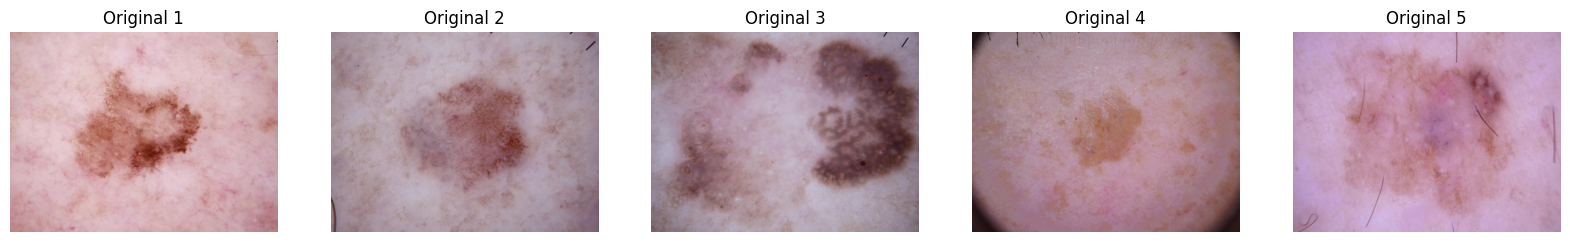

In [9]:
images_rgb = []
images_gray = []

if len(selected_images) == 5:
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        images_rgb.append(rgb_img)
        images_gray.append(gray_img)

        axes[i].imshow(rgb_img)
        axes[i].set_title(f"Original {i+1}")
        axes[i].axis('off')
    plt.show()
else:
    print(f"Expected 5 images, but found {len(selected_images)}.")

**Task-02:Preprocess the image**

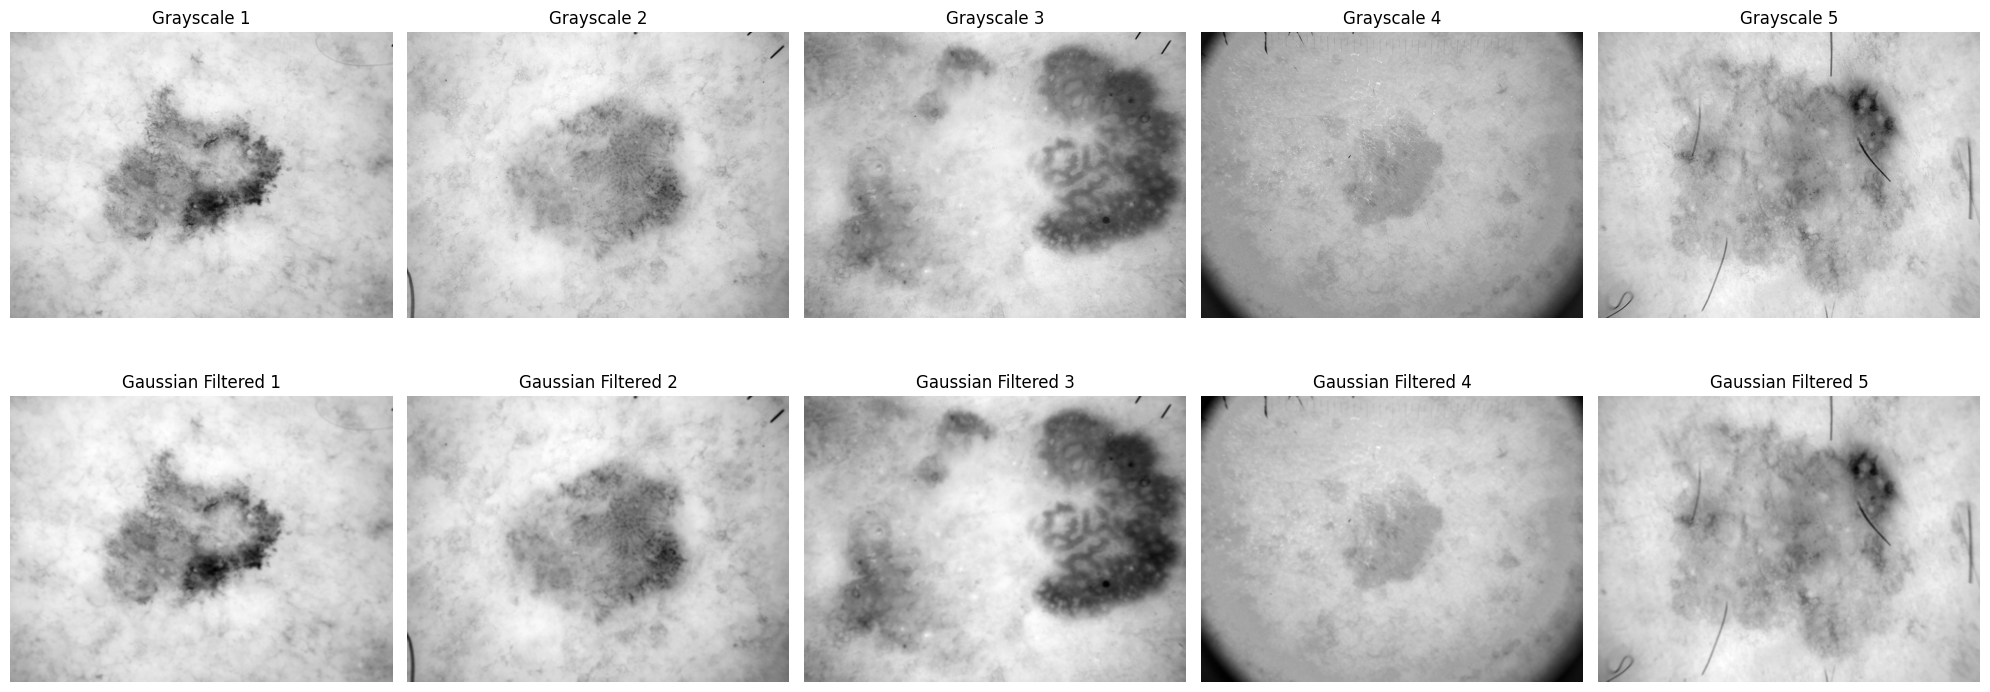

In [10]:
images_gaussian = []

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, gray_img in enumerate(images_gray):
    # Apply Gaussian filter to reduce noise (kernel size 5x5)
    gaussian_img = cv2.GaussianBlur(gray_img, (5, 5), 0)
    images_gaussian.append(gaussian_img)

    axes[0, i].imshow(gray_img, cmap='gray')
    axes[0, i].set_title(f"Grayscale {i+1}")
    axes[0, i].axis('off')

    axes[1, i].imshow(gaussian_img, cmap='gray')
    axes[1, i].set_title(f"Gaussian Filtered {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**Task 3 & 4: Apply Canny Edge Detection & Select Best Result**

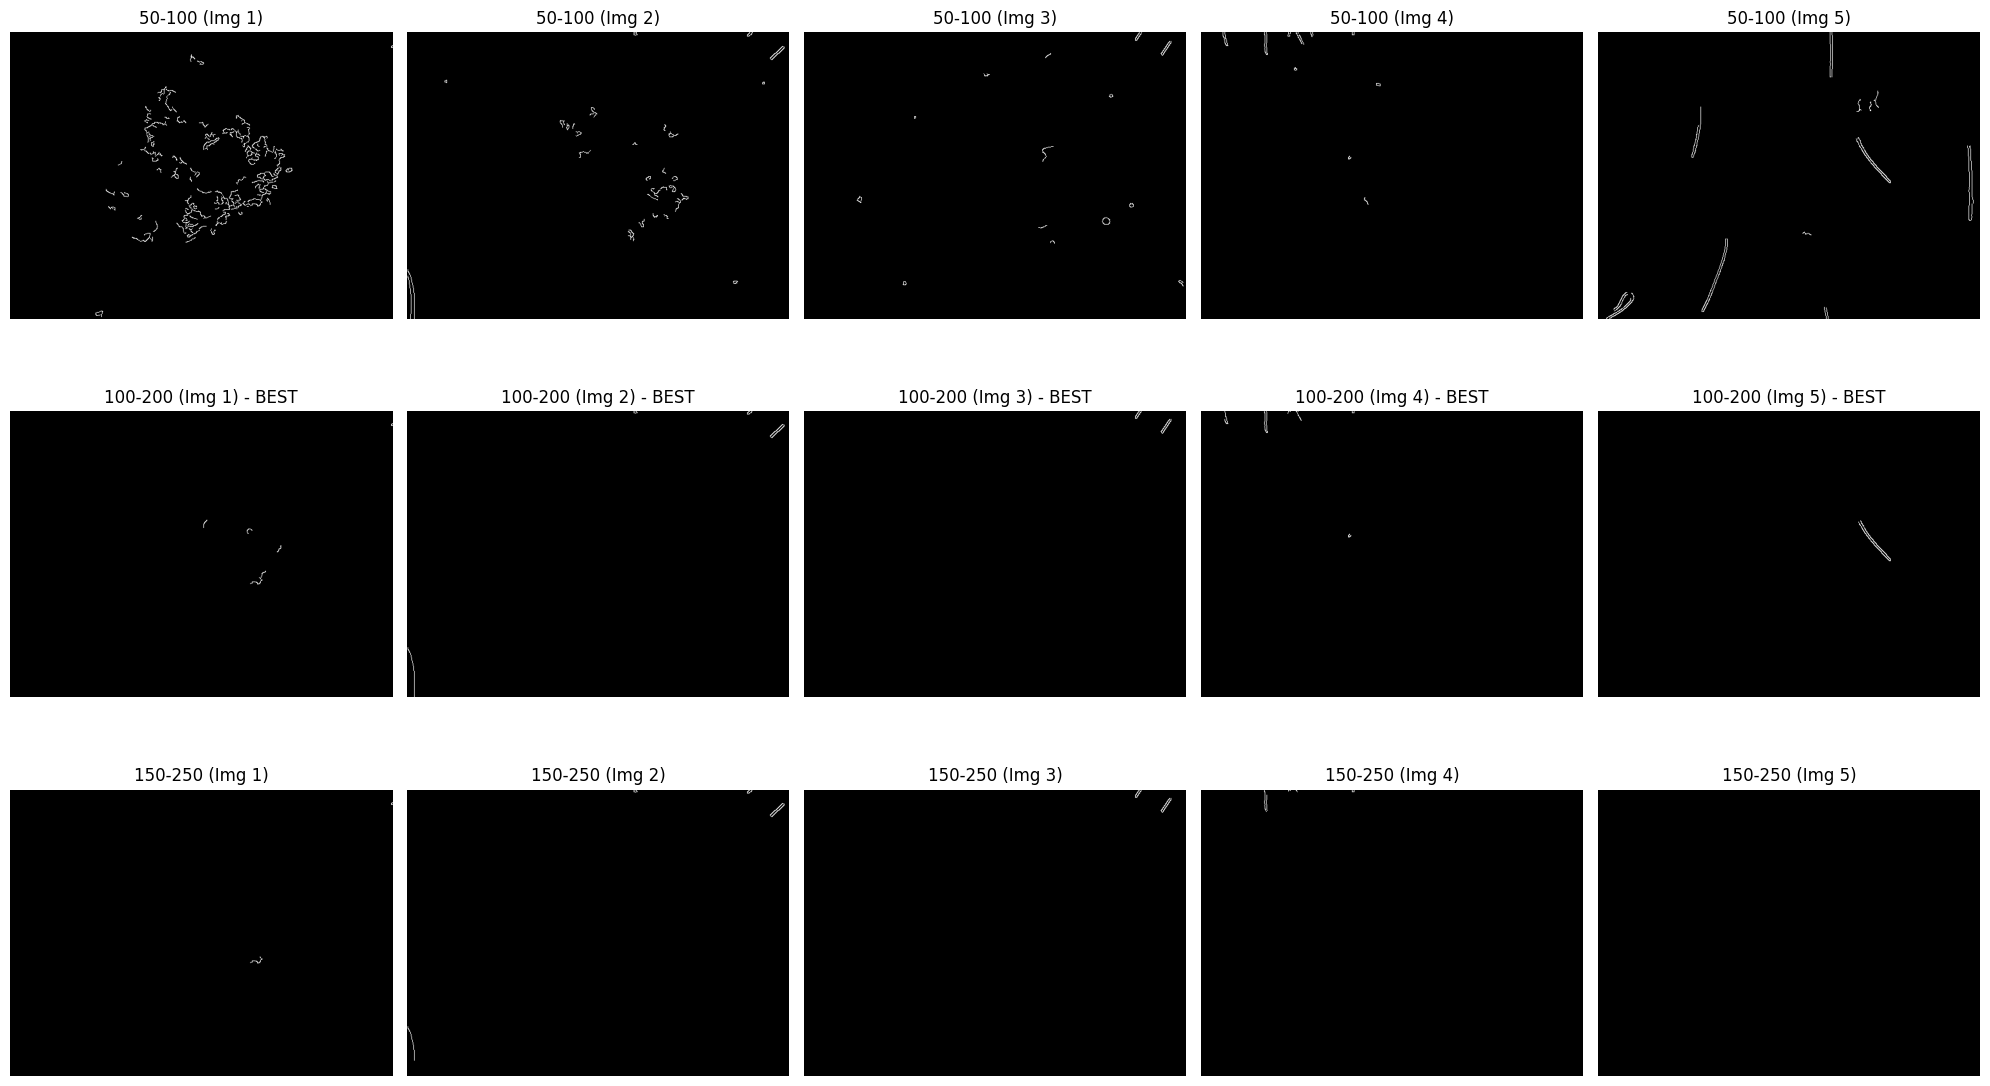

Selection: The threshold of 100-200 provides the clearest boundary.


In [11]:
edges_100_200 = []

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for i, blur_img in enumerate(images_gaussian):
    edge_low = cv2.Canny(blur_img, 50, 100)
    edge_mid = cv2.Canny(blur_img, 100, 200) # This is generally the best threshold
    edge_high = cv2.Canny(blur_img, 150, 250)

    edges_100_200.append(edge_mid)

    axes[0, i].imshow(edge_low, cmap='gray')
    axes[0, i].set_title(f"50-100 (Img {i+1})")
    axes[0, i].axis('off')

    axes[1, i].imshow(edge_mid, cmap='gray')
    axes[1, i].set_title(f"100-200 (Img {i+1}) - BEST")
    axes[1, i].axis('off')

    axes[2, i].imshow(edge_high, cmap='gray')
    axes[2, i].set_title(f"150-250 (Img {i+1})")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

print("Selection: The threshold of 100-200 provides the clearest boundary.")

**Generating Data for the 'Final Comparison' Table**
*(Testing Original, Average, Gaussian, and Median filters with Sobel and Canny on Image 1)*

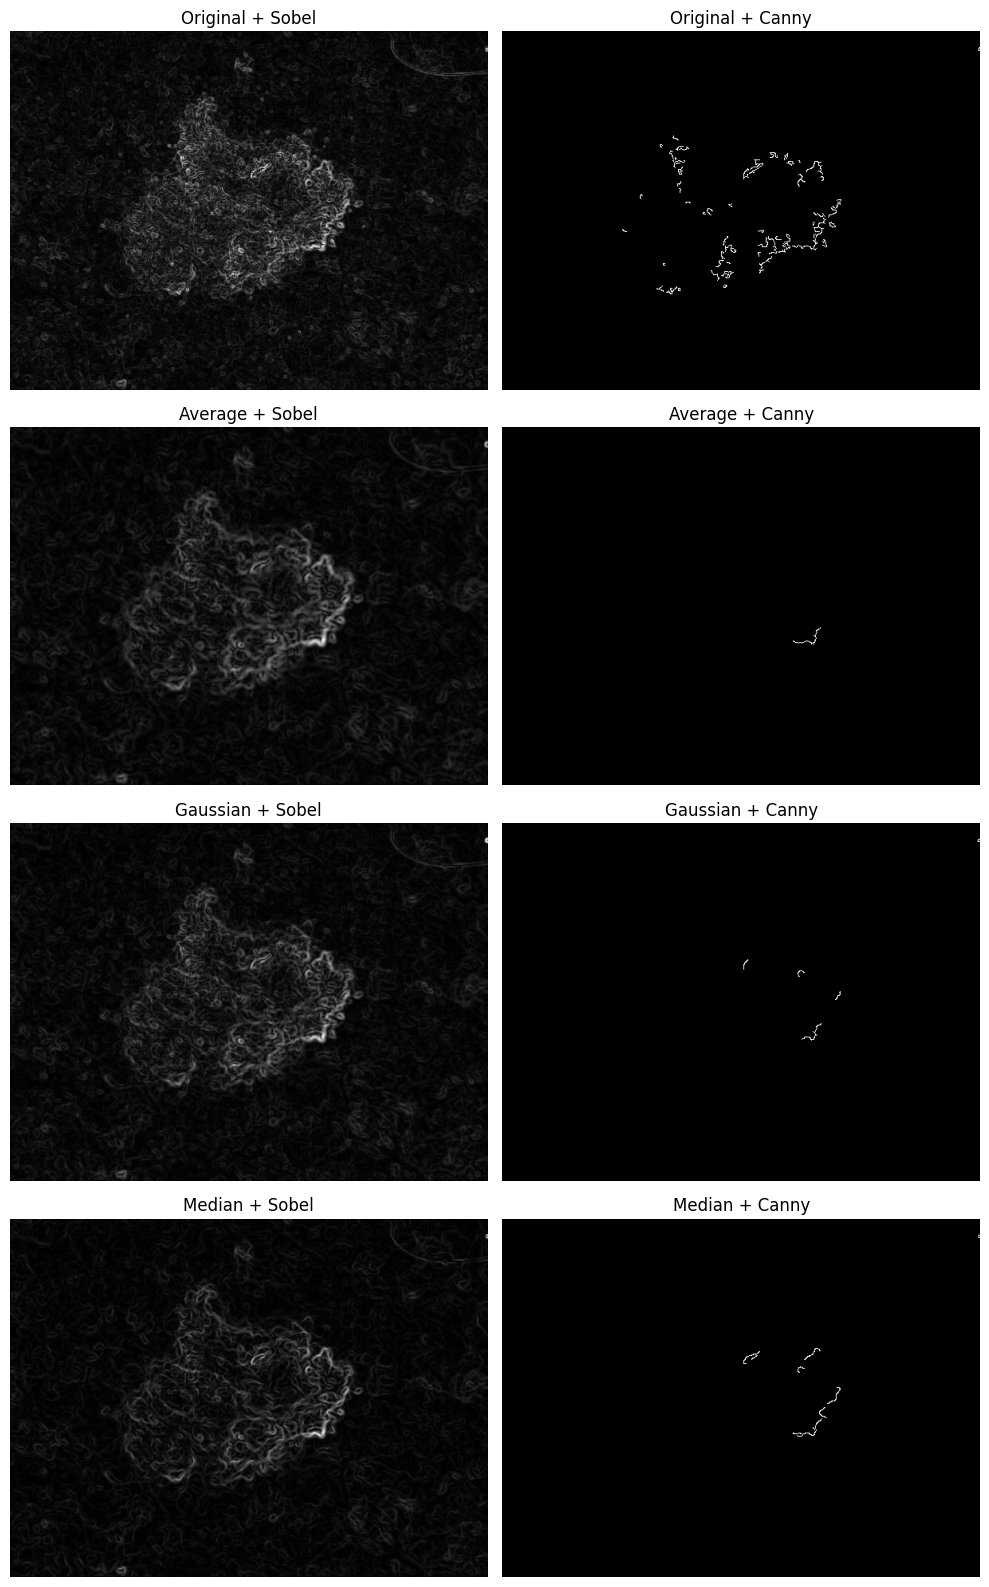

In [12]:
# Take the first image to demonstrate the filter/edge combinations
test_img = images_gray[0]

# 1. Apply Filters
img_orig = test_img
img_avg = cv2.blur(test_img, (5, 5))
img_gauss = cv2.GaussianBlur(test_img, (5, 5), 0)
img_median = cv2.medianBlur(test_img, 5)

filters = {"Original": img_orig, "Average": img_avg, "Gaussian": img_gauss, "Median": img_median}

fig, axes = plt.subplots(4, 2, figsize=(10, 16))

# 2. Apply Edge Detection (Sobel & Canny) to each filtered image
row = 0
for name, f_img in filters.items():
    # Sobel Edge Detection (Combining X and Y)
    sobel_x = cv2.Sobel(f_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(f_img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)
    sobel_combined = np.uint8(np.absolute(sobel_combined))

    # Canny Edge Detection
    canny_edges = cv2.Canny(f_img, 100, 200)

    axes[row, 0].imshow(sobel_combined, cmap='gray')
    axes[row, 0].set_title(f"{name} + Sobel")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(canny_edges, cmap='gray')
    axes[row, 1].set_title(f"{name} + Canny")
    axes[row, 1].axis('off')
    row += 1

plt.tight_layout()
plt.show()

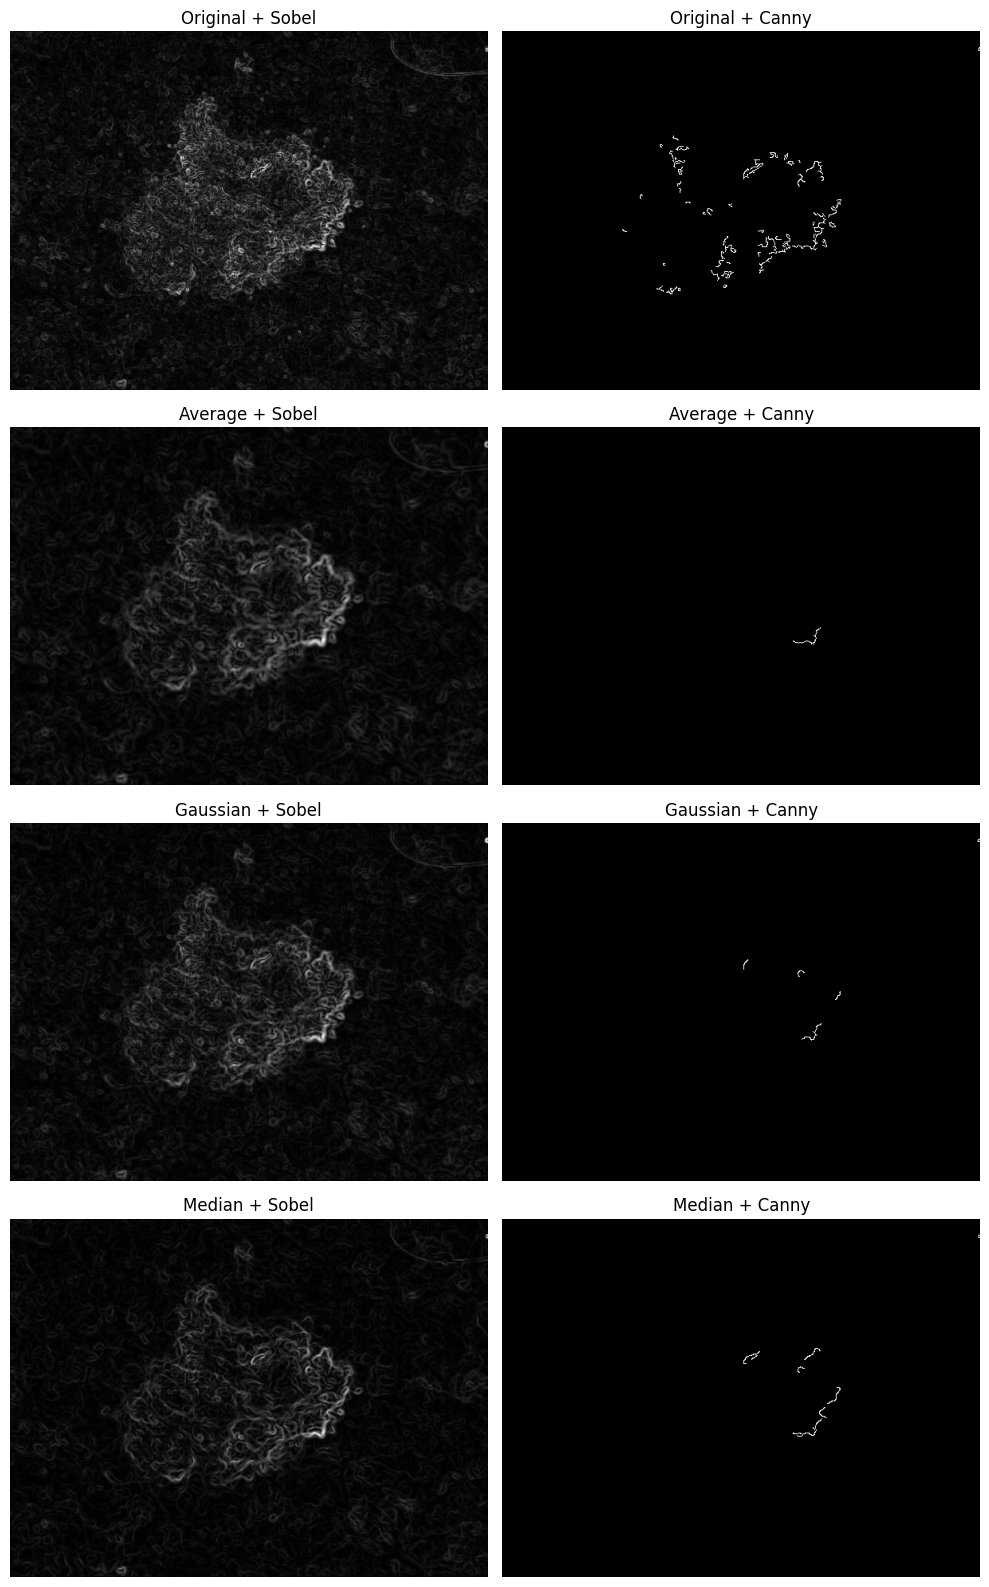

In [13]:
# Take the first image to demonstrate the filter/edge combinations
test_img = images_gray[0]

# 1. Apply Filters
img_orig = test_img
img_avg = cv2.blur(test_img, (5, 5))
img_gauss = cv2.GaussianBlur(test_img, (5, 5), 0)
img_median = cv2.medianBlur(test_img, 5)

filters = {"Original": img_orig, "Average": img_avg, "Gaussian": img_gauss, "Median": img_median}

fig, axes = plt.subplots(4, 2, figsize=(10, 16))

# 2. Apply Edge Detection (Sobel & Canny) to each filtered image
row = 0
for name, f_img in filters.items():
    # Sobel Edge Detection (Combining X and Y)
    sobel_x = cv2.Sobel(f_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(f_img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)
    sobel_combined = np.uint8(np.absolute(sobel_combined))

    # Canny Edge Detection
    canny_edges = cv2.Canny(f_img, 100, 200)

    axes[row, 0].imshow(sobel_combined, cmap='gray')
    axes[row, 0].set_title(f"{name} + Sobel")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(canny_edges, cmap='gray')
    axes[row, 1].set_title(f"{name} + Canny")
    axes[row, 1].axis('off')
    row += 1

plt.tight_layout()
plt.show()

**Task 5 & 6: Detect the Lesion Boundary & Calculate Area/Perimeter**

--- Calculated Metrics ---
Image 1 | Area: 10.50 px | Perimeter: 99.98 px
Image 2 | Area: 113.50 px | Perimeter: 63.15 px
Image 3 | Area: 27.50 px | Perimeter: 112.61 px
Image 4 | Area: 6.00 px | Perimeter: 149.11 px
Image 5 | Area: 92.00 px | Perimeter: 329.53 px


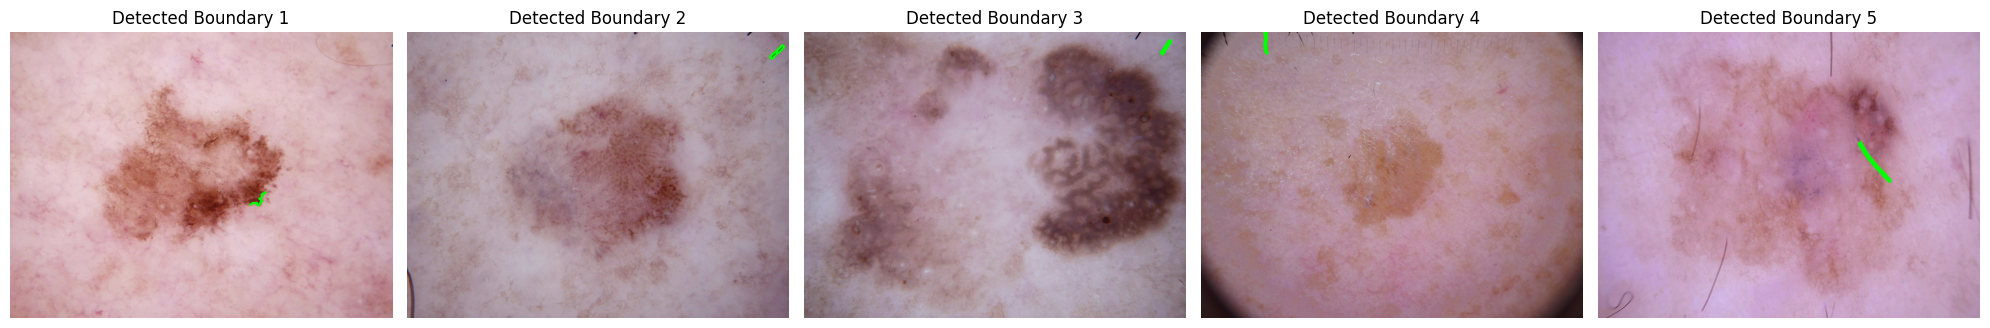

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

print("--- Calculated Metrics ---")
for i in range(5):
    best_edge = edges_100_200[i]
    original_copy = images_rgb[i].copy()

    # Find contours
    contours, hierarchy = cv2.findContours(best_edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Get the largest contour assuming it's the lesion
        lesion_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(original_copy, [lesion_contour], -1, (0, 255, 0), 2)

        area = cv2.contourArea(lesion_contour)
        perimeter = cv2.arcLength(lesion_contour, True)
    else:
        area, perimeter = 0, 0

    print(f"Image {i+1} | Area: {area:.2f} px | Perimeter: {perimeter:.2f} px")

    axes[i].imshow(original_copy)
    axes[i].set_title(f"Detected Boundary {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()